In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "src/nsdata").is_dir())
sys.path.insert(0, str(root / "src"))
from nsdata import PeriodicNavierStokes
from phfno.fourier import RealFourierCoordinates

device = torch.device("cuda")
torch.empty(1, device=device)
data = {name: torch.load(root / "datasets" / f"{name}.pt", weights_only=True) for name in ("wave", "taylor_green", "random")}
labels = {"wave": "Wave", "taylor_green": "Taylor–Green", "random": "Random"}
kind, sample = "random", 0
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False, "axes.spines.right": False})

In [3]:
reference, errors = {}, {}
for name, dataset in data.items():
    clean = dataset["clean"].to(device=device, dtype=torch.float64)
    forcing = dataset["forcing"].to(device=device, dtype=torch.float64)
    times = dataset["times"]
    n = clean.shape[-1]
    viscosity = dataset["metadata"]["viscosity"]
    if name == "wave":
        solver = PeriodicNavierStokes(n, viscosity, device=device)
        wave_simulated = solver.solve(clean[:, 0], times, max_dt=0.005, forcing=forcing).cpu()
        reference[name] = clean.cpu()
        difference = wave_simulated - reference[name]
    else:
        fine_n = 2 * n
        coordinates = RealFourierCoordinates(((n - 1) // 3,) * 3, channels=3).to(device)
        initial = coordinates.decode(coordinates.encode(clean[:, 0]), (fine_n,) * 3)
        fine_forcing = coordinates.decode(coordinates.encode(forcing.flatten(0, 1)), (fine_n,) * 3)
        fine_forcing = fine_forcing.reshape(*forcing.shape[:3], fine_n, fine_n, fine_n)
        solver = PeriodicNavierStokes(fine_n, viscosity, device=device)
        reference[name] = solver.solve(
            initial, times, max_dt=dataset["metadata"]["max_dt"] / 2,
            cfl=dataset["metadata"]["cfl"], forcing=fine_forcing,
        ).cpu()
        lifted = coordinates.decode(coordinates.encode(clean.flatten(0, 1)), (fine_n,) * 3)
        lifted = lifted.reshape_as(reference[name]).cpu()
        difference = lifted - reference[name]
    errors[name] = difference.flatten(2).norm(dim=2) / reference[name].flatten(2).norm(dim=2).clamp_min(1e-12)
    assert torch.isfinite(reference[name]).all()
    assert errors[name][:, 0].max() < 1e-6

In [4]:
reference['wave'].shape

torch.Size([4, 21, 3, 16, 16, 16])

In [5]:
divergence, noise_fraction, noise_scale = {}, {}, {}
for name, dataset in data.items():
    clean = dataset["clean"].double()
    noisy = dataset["noisy"].double()
    solver = PeriodicNavierStokes(clean.shape[-1], dataset["metadata"]["viscosity"])
    div = solver.divergence(clean.flatten(0, 1))
    divergence[name] = div.flatten(1).square().mean(1).sqrt().reshape(clean.shape[:2])
    noise = noisy - clean
    noise_fraction[name] = noise.flatten(2).norm(dim=2) / clean.flatten(2).norm(dim=2).clamp_min(1e-12)
    noise_scale[name] = noise.flatten(1).std(dim=1) / dataset["noise_sigma"]
    assert torch.isfinite(clean).all() and torch.isfinite(noisy).all()
    assert divergence[name].max() < 1e-5
    assert torch.allclose(noise_scale[name], torch.ones_like(noise_scale[name]), atol=0.02)

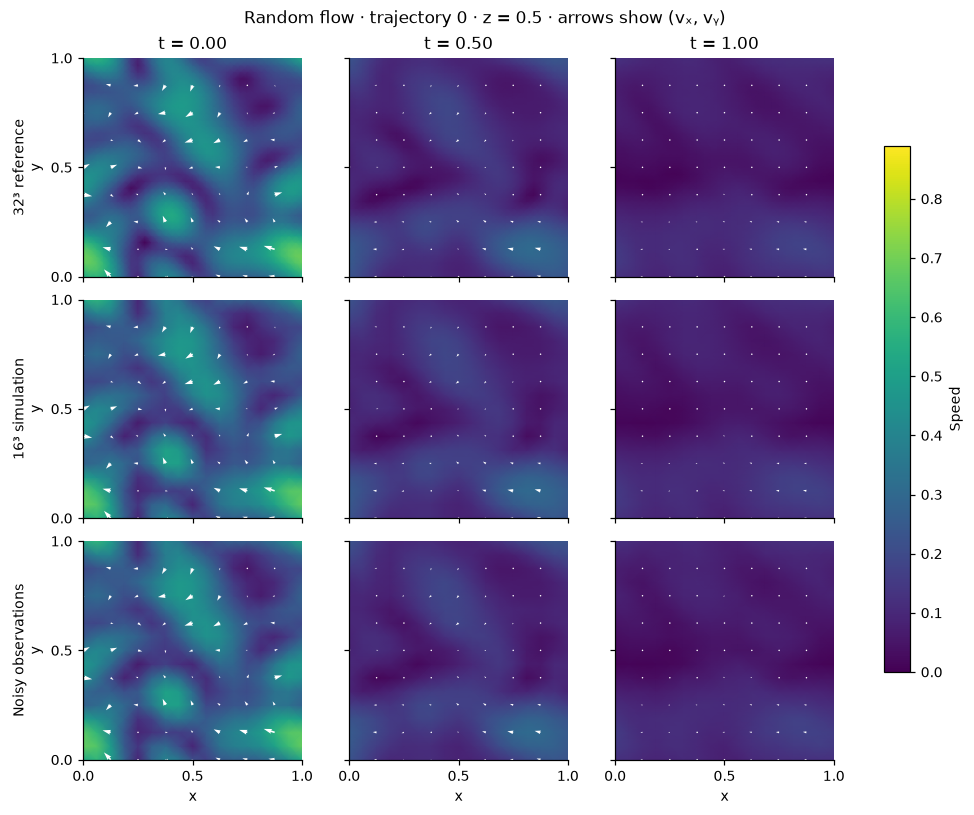

In [6]:
dataset = data[kind]
times = dataset["times"]
snapshots = [0, len(times) // 2, len(times) - 1]
ref_label = "Exact" if kind == "wave" else f"{reference[kind].shape[-1]}³ reference"
simulation = wave_simulated if kind == "wave" else dataset["clean"]
rows = [(ref_label, reference[kind]), (f"{simulation.shape[-1]}³ simulation", simulation), ("Noisy observations", dataset["noisy"])]
limit = max(fields[sample, snapshots].square().sum(1).sqrt().max().item() for _, fields in rows)
fig, axes = plt.subplots(3, 3, figsize=(8.8, 7.3), sharex=True, sharey=True, layout="constrained")
for row, (label, fields) in enumerate(rows):
    for column, index in enumerate(snapshots):
        ax = axes[row, column]
        velocity = fields[sample, index]
        n = velocity.shape[-1]
        plane = velocity[:, :, :, n // 2]
        periodic = torch.arange(n + 1) % n
        speed = plane.square().sum(0).sqrt()[periodic][:, periodic]
        grid = torch.linspace(0, 1, n + 1)
        colors = ax.pcolormesh(grid, grid, speed.T, shading="gouraud", cmap="viridis", vmin=0, vmax=limit)
        stride = max(1, n // 8)
        xy = torch.arange(0, n, stride) / n
        ax.quiver(xy, xy, plane[0, ::stride, ::stride].T, plane[1, ::stride, ::stride].T, color="white", scale=12 * limit)
        ax.set(aspect="equal", xlim=(0, 1), ylim=(0, 1), xticks=[0, 0.5, 1], yticks=[0, 0.5, 1])
        if row == 0:
            ax.set_title(f"t = {times[index]:.2f}")
        if column == 0:
            ax.set_ylabel(f"{label}\ny")
        if row == 2:
            ax.set_xlabel("x")
fig.colorbar(colors, ax=axes, label="Speed", shrink=0.75)
fig.suptitle(f"{labels[kind]} flow · trajectory {sample} · z = 0.5 · arrows show (vₓ, vᵧ)")
plt.show()

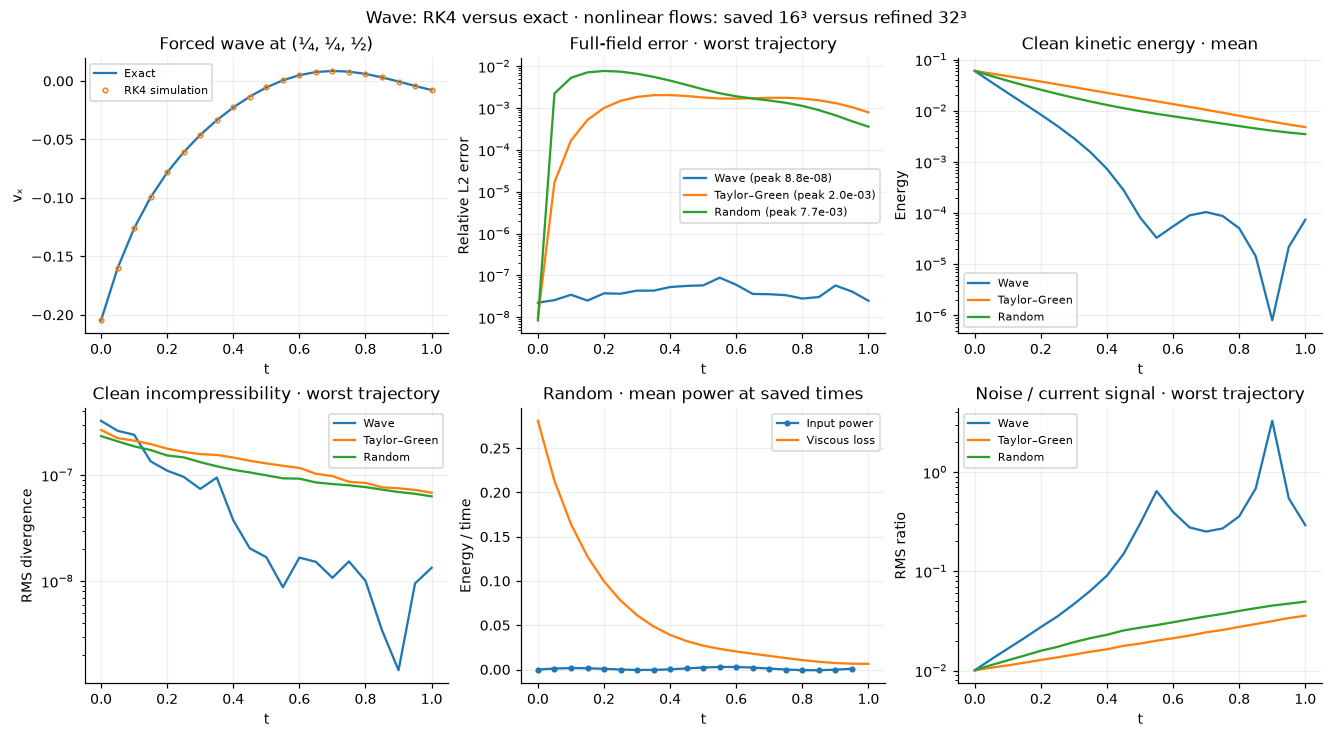

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6.6), layout="constrained")
ax = axes[0, 0]
n = data["wave"]["clean"].shape[-1]
point = (sample, slice(None), 0, n // 4, n // 4, n // 2)
ax.plot(data["wave"]["times"], reference["wave"][point], label="Exact")
ax.plot(data["wave"]["times"], wave_simulated[point], "o", ms=3, fillstyle="none", label="RK4 simulation")
ax.set(title="Forced wave at (¼, ¼, ½)", ylabel="vₓ")
for name, dataset in data.items():
    times = dataset["times"]
    label = labels[name]
    axes[0, 1].semilogy(times, errors[name].amax(0).clamp_min(1e-12), label=f"{label} (peak {errors[name].max():.1e})")
    axes[0, 2].semilogy(times, dataset["diagnostics"]["kinetic_energy"].mean(0), label=label)
    axes[1, 0].semilogy(times, divergence[name].amax(0).clamp_min(1e-12), label=label)
    axes[1, 2].semilogy(times, noise_fraction[name].amax(0), label=label)
axes[0, 1].set(title="Full-field error · worst trajectory", ylabel="Relative L2 error")
axes[0, 2].set(title="Clean kinetic energy · mean", ylabel="Energy")
axes[1, 0].set(title="Clean incompressibility · worst trajectory", ylabel="RMS divergence")
axes[1, 2].set(title="Noise / current signal · worst trajectory", ylabel="RMS ratio")
dataset = data[kind]
diagnostics = dataset["diagnostics"]
axes[1, 1].plot(dataset["times"][:-1], diagnostics["input_power"].mean(0), "o-", ms=3, label="Input power")
axes[1, 1].plot(dataset["times"], diagnostics["dissipation_rate"].mean(0), label="Viscous loss")
axes[1, 1].set(title=f"{labels[kind]} · mean power at saved times", ylabel="Energy / time")
for ax in axes.flat:
    ax.set_xlabel("t")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=7)
fig.suptitle("Wave: RK4 versus exact · nonlinear flows: saved 16³ versus refined 32³")
plt.show()